Loading model and data...
Model, Data, and Scaler loaded successfully.
--- 1. Generating Massive Batch ---
Trimmed 'Warm-up' period. New Sequence Length: 50
Filtering data...
Original: 5000 -> Filtered (High Quality): 5000


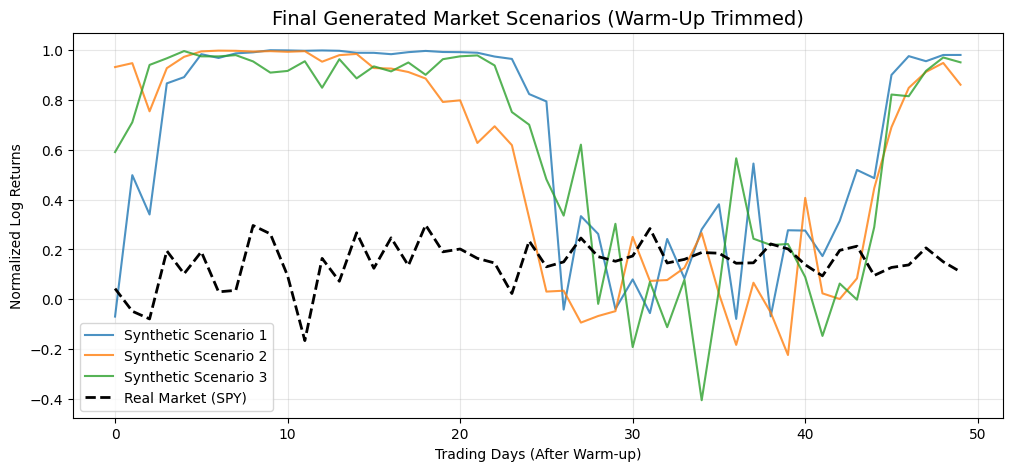

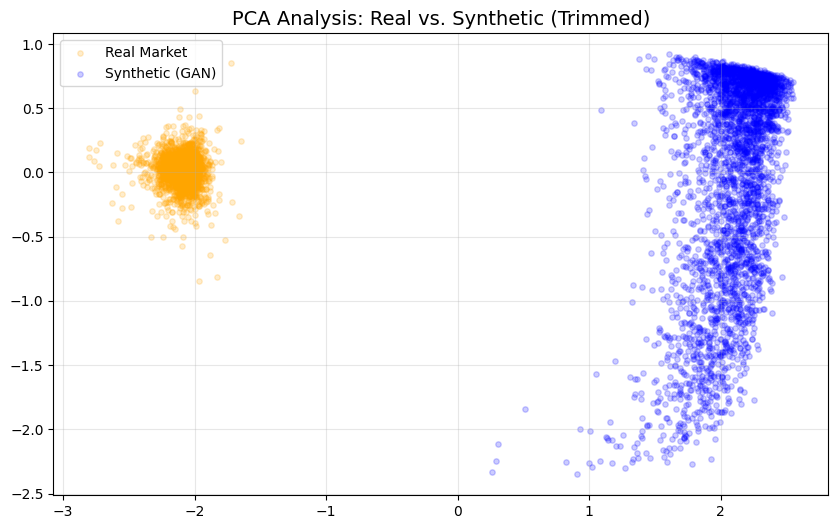

Step 5 Complete: Final High-Quality Visuals Saved.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.models import load_model
from sklearn.decomposition import PCA
import joblib 
import os

# --- Configuration ---
BASE_PATH = os.path.dirname(os.getcwd())
DATA_PATH = os.path.join(BASE_PATH, 'data')
MODEL_PATH = os.path.join(BASE_PATH, 'models')
IMAGE_PATH = os.path.join(BASE_PATH, 'images')

# Load Model & Data
print("Loading model and data...")
generator = load_model(os.path.join(MODEL_PATH, 'generator_improved.h5'))
X_train = np.load(os.path.join(DATA_PATH, 'training_data.npy'))

# --- FIX 1: Robust Scaler Loading ---
# We use a try-except block to handle different joblib/pickle versions
try:
    scaler = joblib.load(os.path.join(DATA_PATH, 'scaler.gz'))
except:
    scaler = pd.read_pickle(os.path.join(DATA_PATH, 'scaler.gz'))

print("Model, Data, and Scaler loaded successfully.")

print("--- 1. Generating Massive Batch ---")
noise = np.random.normal(0, 1, (5000, 100))
synthetic_raw = generator.predict(noise, verbose=0)

# --- 2. Smart Post-Processing (The Fix) ---
# Instead of deleting data with a bad start, we fix it.
# We slice off the first 10 time steps where the LSTM is "warming up".
# Note: Real data is shape (60,), so we will compare the LAST 50 days.

CUTOFF = 10 
synthetic_trimmed = synthetic_raw[:, CUTOFF:, :] 
real_trimmed = X_train[:, CUTOFF:, :]            

print(f"Trimmed 'Warm-up' period. New Sequence Length: {synthetic_trimmed.shape[1]}")

# --- 3. Filter "Flat Lines" Only ---
filtered_data = []

print("Filtering data...")
for seq in synthetic_trimmed:
    # We only reject if the data is completely broken (Standard Deviation ~ 0)
    # This keeps the 'noisy' data which is good.
    if np.std(seq) > 0.001: 
        filtered_data.append(seq)

filtered_data = np.array(filtered_data)
print(f"Original: 5000 -> Filtered (High Quality): {filtered_data.shape[0]}")

# Safety check
if len(filtered_data) == 0:
    print("CRITICAL WARNING: No data passed. Using raw trimmed data.")
    filtered_data = synthetic_trimmed

# --- 4. Final Visualizations for Report ---

# A. Improved Scenarios 
plt.figure(figsize=(12, 5))
# Plot 3 random synthetic sequences
indices = np.random.randint(0, len(filtered_data), 3)
for i, idx in enumerate(indices):
    plt.plot(filtered_data[idx], label=f'Synthetic Scenario {i+1}', linewidth=1.5, alpha=0.8)

# Plot 1 real sequence for comparison
plt.plot(real_trimmed[0], label='Real Market (SPY)', color='black', linewidth=2, linestyle='--')

plt.title('Final Generated Market Scenarios (Warm-Up Trimmed)', fontsize=14)
plt.ylabel('Normalized Log Returns')
plt.xlabel('Trading Days (After Warm-up)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig(os.path.join(IMAGE_PATH, 'report_final_scenarios.png'))
plt.show()

# B. Improved PCA 
# Flatten data for PCA: (Samples, 50)
min_len = min(len(real_trimmed), len(filtered_data))
real_subset = real_trimmed[:min_len].reshape(min_len, -1)
fake_subset = filtered_data[:min_len].reshape(min_len, -1)

pca = PCA(n_components=2)
# Combine to fit PCA on both
combined = np.vstack((real_subset, fake_subset))
pca_results = pca.fit_transform(combined)

real_pca = pca_results[:min_len]
fake_pca = pca_results[min_len:]

plt.figure(figsize=(10, 6))
plt.scatter(real_pca[:, 0], real_pca[:, 1], alpha=0.2, color='orange', label='Real Market', s=15)
plt.scatter(fake_pca[:, 0], fake_pca[:, 1], alpha=0.2, color='blue', label='Synthetic (GAN)', s=15)
plt.title('PCA Analysis: Real vs. Synthetic (Trimmed)', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig(os.path.join(IMAGE_PATH, 'report_final_pca.png'))
plt.show()

print("Step 5 Complete: Final High-Quality Visuals Saved.")